In [27]:
# Import Required Libraries
# Here we are importing the necessary libraries for our task
import pandas as pd # pandas is a software library written for the Python programming language for data manipulation and analysis.

# Load the CSV file from the project root
# The file is in the root of the workspace: C:\CopilotHackathon\exercisefiles\dataengineer\tested_worldwide.csv
# Because the notebook is in the same folder, a relative path works from this location.
df = pd.read_csv('tested_worldwide.csv')

# Display the first few rows so we can inspect the data
# This helps confirm the columns and the structure of the dataset.
print(df.head())


         Date Country_Region Province_State  positive  active  hospitalized  \
0  2020-01-16        Iceland     All States       3.0     NaN           NaN   
1  2020-01-17        Iceland     All States       4.0     NaN           NaN   
2  2020-01-18        Iceland     All States       7.0     NaN           NaN   
3  2020-01-20    South Korea     All States       1.0     NaN           NaN   
4  2020-01-22  United States     All States       0.0     NaN           NaN   

   hospitalizedCurr  recovered  death  total_tested  daily_tested  \
0               NaN        NaN    NaN           NaN           NaN   
1               NaN        NaN    NaN           NaN           NaN   
2               NaN        NaN    NaN           NaN           NaN   
3               NaN        NaN    NaN           4.0           NaN   
4               NaN        NaN    0.0           0.0           NaN   

   daily_positive  
0             NaN  
1             1.0  
2             3.0  
3             NaN  
4         

In [28]:
# Display the first few rows so we can inspect the data
print(df.head())

         Date Country_Region Province_State  positive  active  hospitalized  \
0  2020-01-16        Iceland     All States       3.0     NaN           NaN   
1  2020-01-17        Iceland     All States       4.0     NaN           NaN   
2  2020-01-18        Iceland     All States       7.0     NaN           NaN   
3  2020-01-20    South Korea     All States       1.0     NaN           NaN   
4  2020-01-22  United States     All States       0.0     NaN           NaN   

   hospitalizedCurr  recovered  death  total_tested  daily_tested  \
0               NaN        NaN    NaN           NaN           NaN   
1               NaN        NaN    NaN           NaN           NaN   
2               NaN        NaN    NaN           NaN           NaN   
3               NaN        NaN    NaN           4.0           NaN   
4               NaN        NaN    0.0           0.0           NaN   

   daily_positive  
0             NaN  
1             1.0  
2             3.0  
3             NaN  
4         

In [29]:
# Display the number of rows and columns in the dataframe
num_rows, num_cols = df.shape
print("Number of rows:", num_rows)
print("Number of columns:", num_cols)

Number of rows: 27641
Number of columns: 12


In [30]:
# Display the data type of each column
print(df.dtypes)

Date                    str
Country_Region          str
Province_State          str
positive            float64
active              float64
hospitalized        float64
hospitalizedCurr    float64
recovered           float64
death               float64
total_tested        float64
daily_tested        float64
daily_positive      float64
dtype: object


In [31]:
# Display the number of missing values in each column
print(df.isnull().sum())

Date                    0
Country_Region          0
Province_State          0
positive             4242
active               9833
hospitalized        19231
hospitalizedCurr    13080
recovered            9626
death                4010
total_tested          912
daily_tested         1174
daily_positive       4557
dtype: int64


In [32]:
# Display the number of unique values in each column
unique_values = df.nunique()
print(unique_values)

Date                  297
Country_Region        147
Province_State         81
positive            14998
active               9554
hospitalized         4862
hospitalizedCurr     2904
recovered            9183
death                5641
total_tested        23610
daily_tested        13375
daily_positive       3440
dtype: int64


In [33]:
# Drop the columns that are not needed for our analysis
data = df[['Country_Region', 'positive', 'total_tested']]

In [34]:
#Rename the columns to make them more readable
data.rename(columns={'Country_Region': 'Country', 'positive': 'Positive Cases', 'total_tested': 'Total Tested'}, inplace=True)

In [35]:
# Drop the rows that have missing values
data.dropna(inplace=True)

In [36]:
#Convert the data types of the columns to the appropriate types
data['Positive Cases'] = data['Positive Cases'].astype(int)
data['Total Tested'] = data['Total Tested'].astype(int)
data['Country'] = data['Country'].astype('category')

In [37]:
#Display the number of missing values in each column
print(data.isnull().sum())

Country           0
Positive Cases    0
Total Tested      0
dtype: int64


In [38]:
# Group the data by 'Country' and calculate the sum of 'Positive Cases'
total_positive_cases = data.groupby('Country')['Positive Cases'].sum()
# Create a new dataframe with the total positive cases for each country
df_total_positive_cases = pd.DataFrame({'Country': total_positive_cases.index, 'Total Positive Cases': total_positive_cases.values})
# Display the new dataframe
df_total_positive_cases

,Country,Total Positive Cases
0,Albania,12279
1,Argentina,28220
2,Armenia,7225809
3,Australia,20654
4,Austria,541013
...,...,...
112,United States,1837768204
113,Uruguay,2160
114,Veneto,119910
115,Venezuela,461


In [39]:
# Sort the dataframe in descending order of the total number of positive cases
df_total_positive_cases = df_total_positive_cases.sort_values('Total Positive Cases', ascending=False)

In [40]:
# Display the top ten countries with the most positive cases
print(df_total_positive_cases.head(10))

            Country  Total Positive Cases
112   United States            1837768204
48            Italy              64199206
17           Canada              50960416
7        Bangladesh              43771939
106          Turkey              16556127
26          Czechia              10822251
88           Russia              10663267
2           Armenia               7225809
21       Costa Rica               6655702
111  United Kingdom               4924956


In [41]:
# Group the data by 'Country' and calculate the sum of 'Total Tested'
total_tests = data.groupby('Country')['Total Tested'].sum()

# Create a new dataframe with the total tests conducted for each country
df_total_tests = pd.DataFrame({'Country': total_tests.index, 'Total Tests Conducted': total_tests.values})

# Display the new dataframe
df_total_tests

,Country,Total Tests Conducted
0,Albania,114611
1,Argentina,323035
2,Armenia,35667650
3,Australia,323233309
4,Austria,7610548
...,...,...
112,United States,23592177772
113,Uruguay,51789
114,Veneto,1650118
115,Venezuela,395904


In [42]:
# Sort the dataframe in descending order of the total number of tests conducted
df_total_tests = df_total_tests.sort_values('Total Tests Conducted', ascending=False)

In [43]:
# Display the top ten countries with the most tests conducted
print(df_total_tests.head(10))

           Country  Total Tests Conducted
112  United States            23592177772
17          Canada             1797986542
48           Italy             1547472209
47          Israel              388197039
3        Australia              323233309
88          Russia              300300499
7       Bangladesh              233149800
106         Turkey              228325949
26         Czechia              180065598
39          Greece              142101237


In [44]:
# Merge the two country-level summary dataframes on the country name
merged_df = df_total_positive_cases.merge(df_total_tests, on='Country', how='inner')

# Display the merged dataframe
merged_df.head()

,Country,Total Positive Cases,Total Tests Conducted
0,United States,1837768204,23592177772
1,Italy,64199206,1547472209
2,Canada,50960416,1797986542
3,Bangladesh,43771939,233149800
4,Turkey,16556127,228325949


In [45]:
# Create a new column that contains the ratio of positive cases to the number of tests conducted
merged_df['Positive Test Rate'] = merged_df['Total Positive Cases'] / merged_df['Total Tests Conducted']
# Sort the dataframe in descending order of the ratio of positive cases to the number of tests conducted
merged_df = merged_df.sort_values('Positive Test Rate', ascending=False)
#Display the top three countries with the highest ratio of positive cases to the number of tests conducted
top_countries = merged_df.nlargest(3, 'Positive Test Rate')
top_countries[['Country', 'Positive Test Rate']]

,Country,Positive Test Rate
106,Tanzania,0.780675
103,Burkina Faso,0.480870
50,Ecuador,0.322330


<Axes: xlabel='Country'>

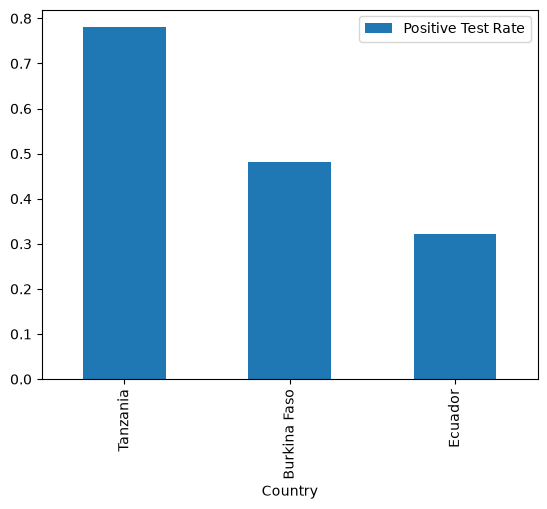

In [46]:
# Display the results a chart that shows the top three countries with the highest ratio of positive cases to the number
import matplotlib.pyplot as plt
top_countries.plot(x='Country', y='Positive Test Rate', kind='bar')


<Axes: xlabel='Country'>

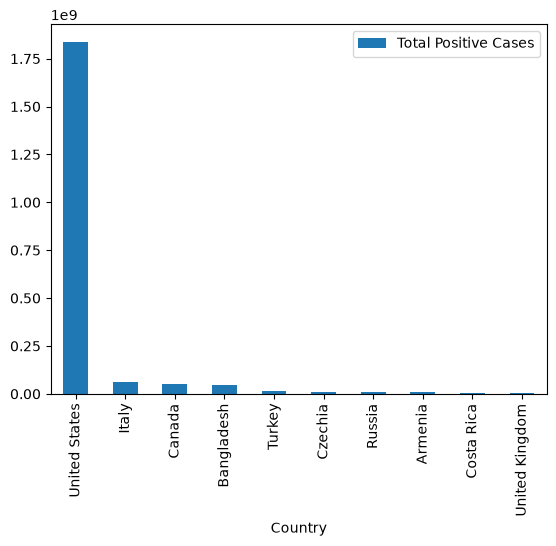

In [47]:
# Display the results in a chart that shows the top ten countries with the most positive cases
top_ten_countries = merged_df.nlargest(10, 'Total Positive Cases')
top_ten_countries.plot(x='Country', y='Total Positive Cases', kind='bar')

<Axes: xlabel='Country'>

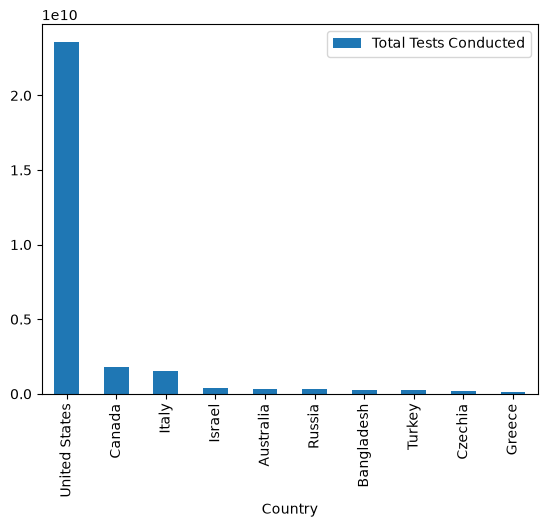

In [48]:
# Display the results in a chart that shows the top ten countries with the most tests conducted
top_ten_tests = merged_df.nlargest(10, 'Total Tests Conducted')
top_ten_tests.plot(x='Country', y='Total Tests Conducted', kind='bar')